In [1]:
"""
Phase 6: Topic Modelling, Keyword Frequency & Co-occurrence — Wired vs The Verge
================================================================================
Inputs : data/processed/wired_posts_sentiment.csv, verge_posts_sentiment.csv
Outputs: outputs/figures/10-13_*.png, outputs/tables/08-10_*.csv,
         data/processed/topics_summary.json,
         data/processed/wired_posts_topics.csv, verge_posts_topics.csv

Approach:
  - Keyword frequency: top tokens from text_clean_no_brand (brand tokens removed
    so the topic is the discourse, not the brand name).
  - LDA topic modelling via gensim, k chosen by coherence (c_v) over k = 4..8.
    Each post is then assigned its dominant topic for downstream analysis.
  - Word co-occurrence network: edges between tokens that appear in the same
    post; centrality used to surface anchor concepts per brand.
"""
import json
import warnings
from collections import Counter
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

# pip install gensim wordcloud
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel
from wordcloud import WordCloud

warnings.filterwarnings("ignore", category=DeprecationWarning)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROC_DIR = PROJECT_ROOT / "data" / "processed"
FIG_DIR  = PROJECT_ROOT / "outputs" / "figures"
TAB_DIR  = PROJECT_ROOT / "outputs" / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
BRAND_COLORS = {"Wired": "#1A1A1A", "The Verge": "#FA4B2A"}

wired_posts = pd.read_csv(PROC_DIR / "wired_posts_sentiment.csv")
verge_posts = pd.read_csv(PROC_DIR / "verge_posts_sentiment.csv")

# Replace any NaN cleaned-text with empty string (downstream code expects str)
for df in (wired_posts, verge_posts):
    df["text_clean"]          = df["text_clean"].fillna("").astype(str)
    df["text_clean_no_brand"] = df["text_clean_no_brand"].fillna("").astype(str)

print(f"Loaded {len(wired_posts)} Wired and {len(verge_posts)} Verge posts.")

Loaded 1090 Wired and 1156 Verge posts.


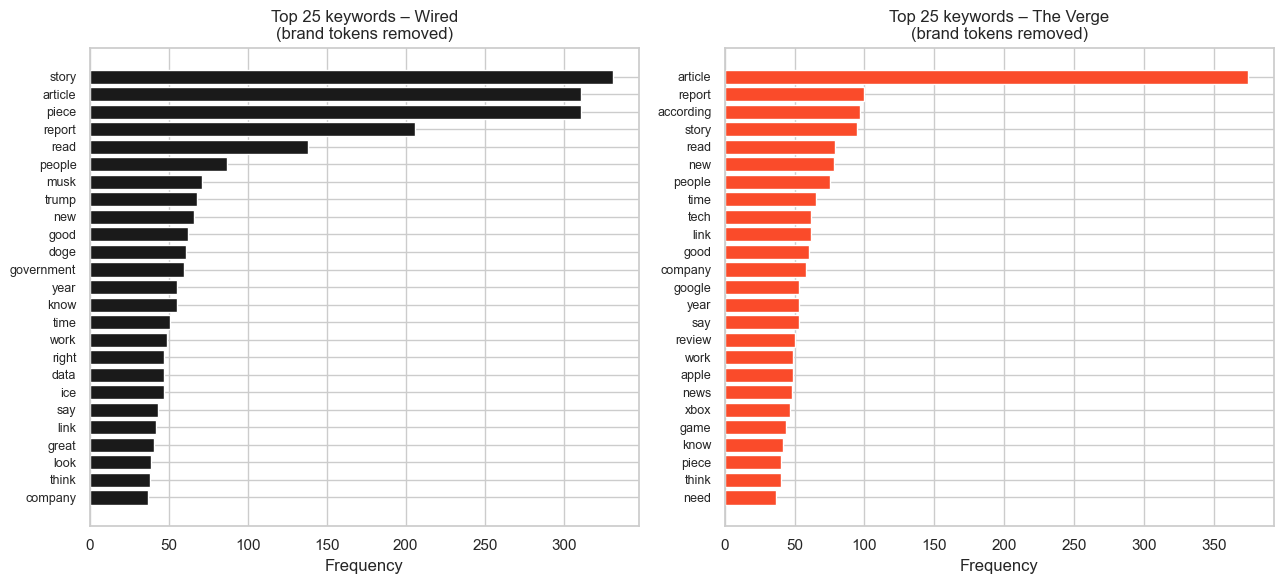

Distinctive to Wired (count_wired, count_verge):
  piece               311 vs   40
  story               331 vs   95
  report              206 vs  100
  doge                 61 vs    0
  government           60 vs    0
  read                138 vs   79
  ice                  47 vs    0
  musk                 71 vs   31
  security             35 vs    0
  elon                 35 vs    0
  trump                68 vs   34
  thought              32 vs    0
  access               32 vs    0
  agency               30 vs    0
  point                28 vs    0

Distinctive to Verge (count_verge, count_wired):
  according            97 vs    0
  article             374 vs  311
  google               53 vs    0
  review               50 vs    0
  apple                49 vs    0
  xbox                 47 vs    0
  game                 44 vs    0
  tech                 62 vs   25
  model                36 vs    0
  podcast              35 vs    0
  love                 34 vs    0
  openai         

In [2]:
def top_keywords(df: pd.DataFrame, col: str = "text_clean_no_brand", n: int = 25) -> list[tuple[str, int]]:
    counter = Counter()
    for txt in df[col]:
        if txt:
            counter.update(txt.split())
    return counter.most_common(n)

wired_kw = top_keywords(wired_posts)
verge_kw = top_keywords(verge_posts)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, (brand, kws) in zip(axes, [("Wired", wired_kw), ("The Verge", verge_kw)]):
    labels, counts = zip(*kws)
    ax.barh(range(len(labels)), counts, color=BRAND_COLORS[brand])
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=9)
    ax.invert_yaxis()
    ax.set_title(f"Top 25 keywords – {brand}\n(brand tokens removed)")
    ax.set_xlabel("Frequency")
plt.tight_layout()
plt.savefig(FIG_DIR / "10_top_keywords.png", dpi=150, bbox_inches="tight")
plt.show()

pd.DataFrame(wired_kw, columns=["keyword", "count"]).to_csv(TAB_DIR / "08_wired_top_keywords.csv", index=False)
pd.DataFrame(verge_kw, columns=["keyword", "count"]).to_csv(TAB_DIR / "08_verge_top_keywords.csv", index=False)

# Distinctive keywords — what does Wired talk about that Verge doesn't, and vice versa?
wired_set, verge_set = dict(top_keywords(wired_posts, n=80)), dict(top_keywords(verge_posts, n=80))
distinctive_wired = sorted(
    [(k, v, verge_set.get(k, 0)) for k, v in wired_set.items()],
    key=lambda x: x[1] - x[2], reverse=True
)[:15]
distinctive_verge = sorted(
    [(k, verge_set.get(k, 0), wired_set.get(k, 0)) for k in verge_set],
    key=lambda x: x[1] - x[2], reverse=True
)[:15]
print("Distinctive to Wired (count_wired, count_verge):")
for k, w, v in distinctive_wired: print(f"  {k:<18} {w:>4} vs {v:>4}")
print("\nDistinctive to Verge (count_verge, count_wired):")
for k, v, w in distinctive_verge: print(f"  {k:<18} {v:>4} vs {w:>4}")

In [3]:
# Tokenise the brand-stripped cleaned text. Filter rare tokens (< 5 docs) and
# very common tokens (> 60% of docs) to focus LDA on discriminating vocabulary.
def build_corpus(df: pd.DataFrame, no_below: int = 5, no_above: float = 0.6):
    docs = [txt.split() for txt in df["text_clean_no_brand"] if txt]
    dictionary = corpora.Dictionary(docs)
    dictionary.filter_extremes(no_below=no_below, no_above=no_above)
    corpus = [dictionary.doc2bow(d) for d in docs]
    return docs, dictionary, corpus

wired_docs, wired_dict, wired_corp = build_corpus(wired_posts)
verge_docs, verge_dict, verge_corp = build_corpus(verge_posts)

print(f"Wired   : {len(wired_docs)} docs, vocab {len(wired_dict)}")
print(f"Verge   : {len(verge_docs)} docs, vocab {len(verge_dict)}")

Wired   : 1090 docs, vocab 728
Verge   : 1156 docs, vocab 728


In [5]:
def coherence_for_k(
    docs,
    dictionary,
    corpus,
    k_values=(4, 5, 6, 7, 8),
    seed: int = 42
) -> dict[int, float]:
    scores: dict[int, float] = {}

    for k in k_values:
        model = LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=k,
            random_state=seed,
            passes=10,
            iterations=200,
            alpha="auto",
        )

        cm = CoherenceModel(
            model=model,
            texts=docs,
            dictionary=dictionary,
            coherence="c_v"
        )

        score = float(cm.get_coherence())
        scores[int(k)] = score

        print(f"  k={k}  coherence={score:.4f}")

    return scores


print("Wired — coherence by k:")
wired_scores = coherence_for_k(wired_docs, wired_dict, wired_corp)

print("\nThe Verge — coherence by k:")
verge_scores = coherence_for_k(verge_docs, verge_dict, verge_corp)


best_k_wired = max(wired_scores.keys(), key=lambda k: wired_scores[k])
best_k_verge = max(verge_scores.keys(), key=lambda k: verge_scores[k])

print(f"\nBest k — Wired: {best_k_wired}, Verge: {best_k_verge}")

Wired — coherence by k:
  k=4  coherence=0.2756
  k=5  coherence=0.2719
  k=6  coherence=0.2868
  k=7  coherence=0.2977
  k=8  coherence=0.2869

The Verge — coherence by k:
  k=4  coherence=0.3091
  k=5  coherence=0.3160
  k=6  coherence=0.3358
  k=7  coherence=0.3303
  k=8  coherence=0.3602

Best k — Wired: 7, Verge: 8


In [6]:
def fit_lda(corpus, dictionary, k, seed: int = 42):
    return LdaModel(
        corpus=corpus, id2word=dictionary, num_topics=k,
        random_state=seed, passes=20, iterations=400, alpha="auto",
    )

wired_lda = fit_lda(wired_corp, wired_dict, best_k_wired)
verge_lda = fit_lda(verge_corp, verge_dict, best_k_verge)

def topics_table(lda_model, label: str, top_n: int = 10) -> pd.DataFrame:
    rows = []
    for tid in range(lda_model.num_topics):
        terms = [w for w, _ in lda_model.show_topic(tid, topn=top_n)]
        rows.append({"brand": label, "topic_id": tid, "top_terms": ", ".join(terms)})
    return pd.DataFrame(rows)

wired_topics_df = topics_table(wired_lda, "Wired")
verge_topics_df = topics_table(verge_lda, "The Verge")
topics_df = pd.concat([wired_topics_df, verge_topics_df], ignore_index=True)
print(topics_df.to_string(index=False))
topics_df.to_csv(TAB_DIR / "09_lda_topics.csv", index=False)

    brand  topic_id                                                                      top_terms
    Wired         0        article, piece, great, report, story, read, know, data, people, already
    Wired         1        story, piece, article, read, good, year, time, people, thought, reading
    Wired         2    article, report, story, government, lorenz, taylor, read, musk, need, piece
    Wired         3      report, piece, story, access, doge, government, treasury, data, new, musk
    Wired         4 story, piece, right, article, report, people, medium, public, know, government
    Wired         5          ice, story, article, report, piece, question, new, thiel, doge, agent
    Wired         6     article, piece, report, read, musk, trump, reporting, company, people, say
The Verge         0        article, medium, report, openai, new, social, say, game, bit, according
The Verge         1   article, something, according, news, user, mention, know, apple, need, month
The Verge 

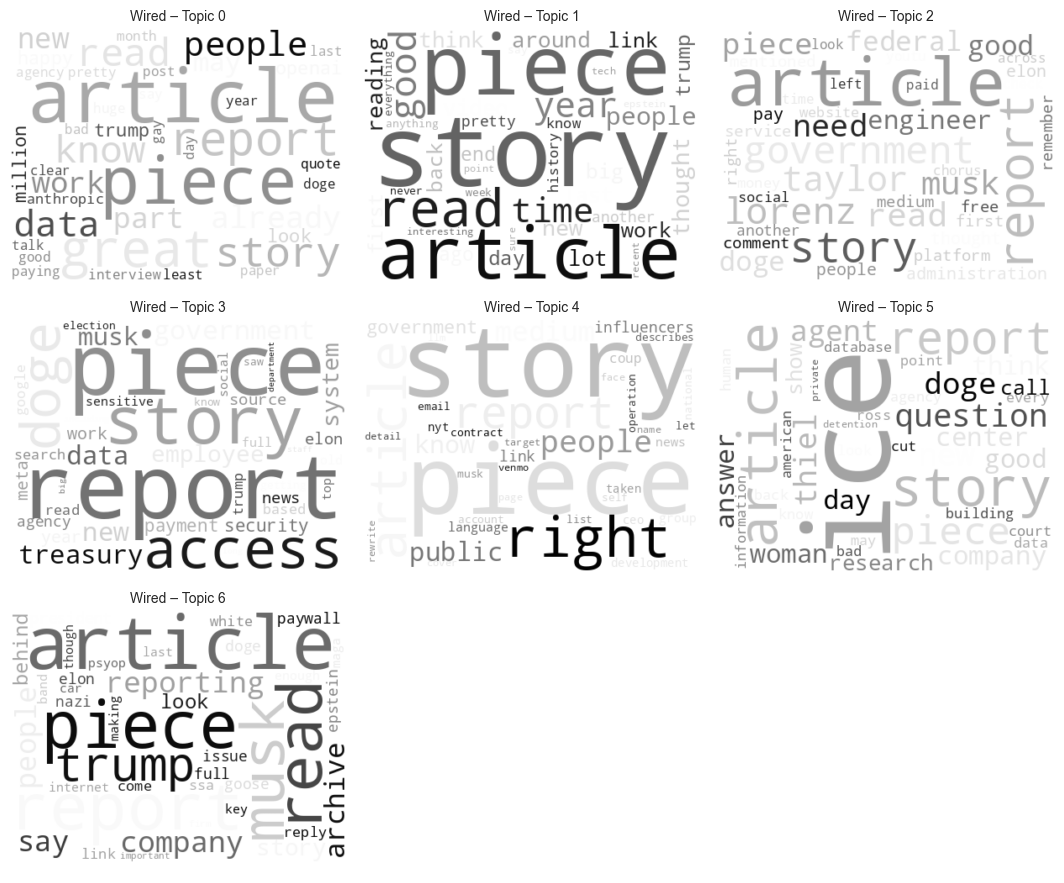

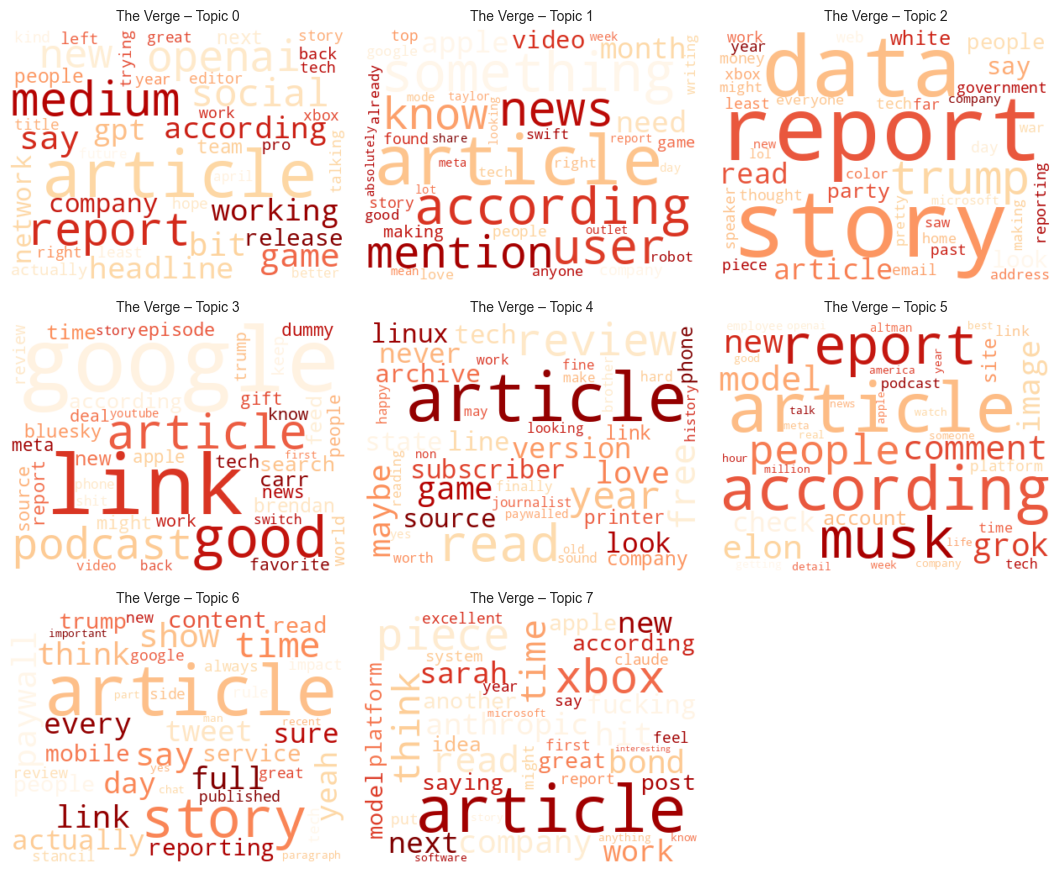

In [7]:
def plot_topic_clouds(lda_model, brand: str, fname: str) -> None:
    k = lda_model.num_topics
    cols = 3
    rows = int(np.ceil(k / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.6, rows * 3))
    axes = np.atleast_2d(axes).flatten()
    for tid in range(k):
        topic_words = dict(lda_model.show_topic(tid, topn=40))
        wc = WordCloud(width=400, height=300, background_color="white",
                       colormap="Greys" if brand == "Wired" else "OrRd")\
                .generate_from_frequencies(topic_words)
        axes[tid].imshow(wc, interpolation="bilinear")
        axes[tid].set_title(f"{brand} – Topic {tid}", fontsize=10)
        axes[tid].axis("off")
    for ax in axes[k:]:
        ax.axis("off")
    plt.tight_layout()
    plt.savefig(FIG_DIR / fname, dpi=150, bbox_inches="tight")
    plt.show()

plot_topic_clouds(wired_lda, "Wired",     "11_wired_topic_clouds.png")
plot_topic_clouds(verge_lda, "The Verge", "11_verge_topic_clouds.png")

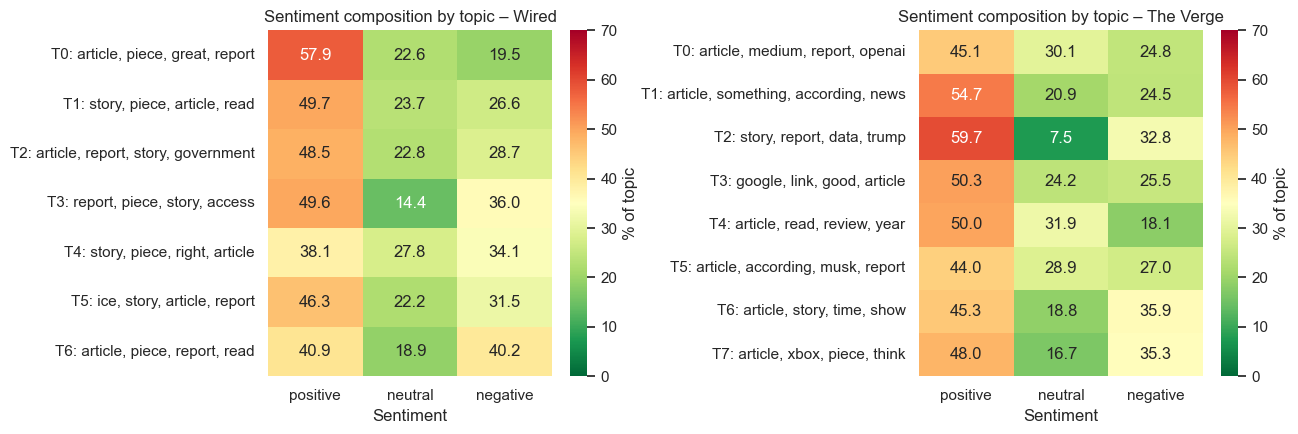

In [8]:
def assign_dominant_topic(lda_model, dictionary, df: pd.DataFrame) -> pd.DataFrame:
    topics = []
    for txt in df["text_clean_no_brand"]:
        if not txt:
            topics.append((-1, 0.0))
            continue
        bow = dictionary.doc2bow(txt.split())
        if not bow:
            topics.append((-1, 0.0))
            continue
        dist = lda_model.get_document_topics(bow, minimum_probability=0.0)
        top = max(dist, key=lambda x: x[1])
        topics.append((int(top[0]), float(top[1])))
    out = df.copy()
    out["topic_id"]   = [t[0] for t in topics]
    out["topic_prob"] = [t[1] for t in topics]
    return out

wired_posts_t = assign_dominant_topic(wired_lda, wired_dict, wired_posts)
verge_posts_t = assign_dominant_topic(verge_lda, verge_dict, verge_posts)

wired_posts_t.to_csv(PROC_DIR / "wired_posts_topics.csv", index=False)
verge_posts_t.to_csv(PROC_DIR / "verge_posts_topics.csv", index=False)

# Topic × sentiment heatmap — which topics drive positivity vs negativity?
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, df, brand, lda in [
    (axes[0], wired_posts_t, "Wired", wired_lda),
    (axes[1], verge_posts_t, "The Verge", verge_lda),
]:
    valid = df[df["topic_id"] >= 0].copy()
    pivot = (
        valid.groupby(["topic_id", "sentiment"]).size()
        .unstack(fill_value=0).reindex(columns=["positive", "neutral", "negative"], fill_value=0)
    )
    pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
    pivot_pct.index = [f"T{tid}: {', '.join(w for w, _ in lda.show_topic(tid, topn=4))}"
                       for tid in pivot_pct.index]
    sns.heatmap(pivot_pct, annot=True, fmt=".1f", cmap="RdYlGn_r",
                cbar_kws={"label": "% of topic"}, ax=ax,
                vmin=0, vmax=70)
    ax.set_title(f"Sentiment composition by topic – {brand}")
    ax.set_xlabel("Sentiment")
    ax.set_ylabel("")
plt.tight_layout()
plt.savefig(FIG_DIR / "12_topic_sentiment_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

Wired co-occurrence graph: 60 nodes, 330 edges
Verge co-occurrence graph: 60 nodes, 236 edges


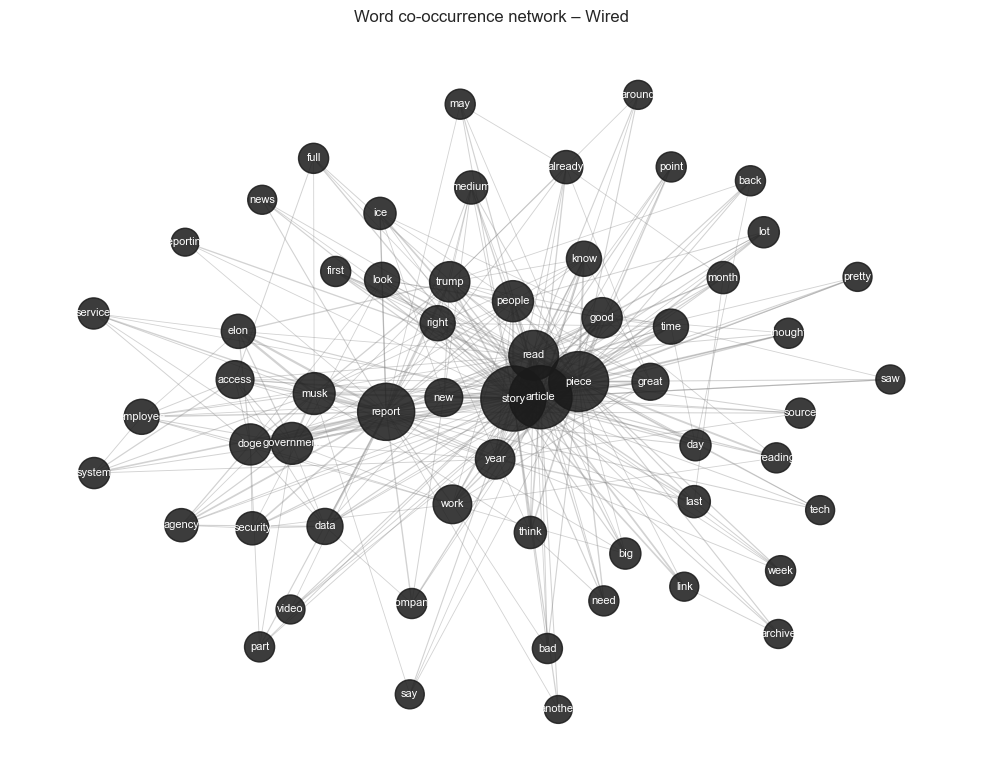

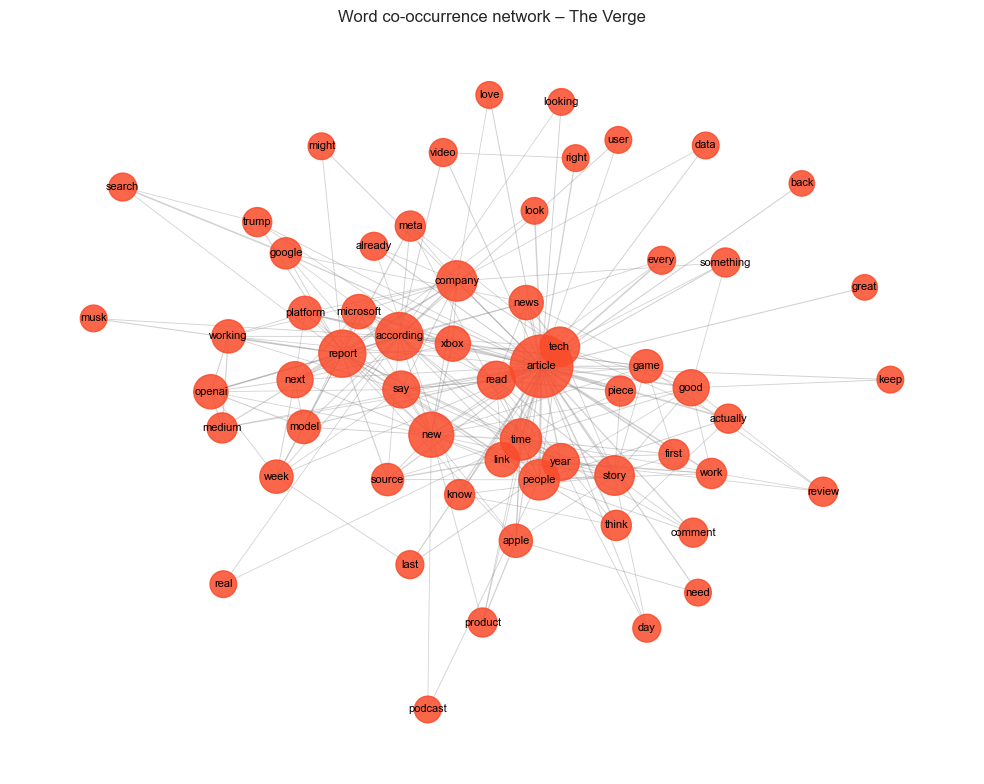


Top 10 most central tokens — Wired:
     token  degree_centrality  frequency
     story           0.949153        308
   article           0.881356        285
     piece           0.779661        296
    report           0.694915        200
      read           0.491525        124
government           0.305085         52
      musk           0.305085         67
    people           0.288136         79
      doge           0.288136         51
     trump           0.271186         60

Top 10 most central tokens — The Verge:
    token  degree_centrality  frequency
  article           0.864407        349
according           0.440678         95
   report           0.423729         99
      new           0.372881         72
     time           0.288136         55
  company           0.271186         54
   people           0.271186         65
     tech           0.254237         59
    story           0.254237         89
     read           0.220339         78

Saved data/processed/topics_su

In [9]:
def cooccurrence_graph(df: pd.DataFrame, top_vocab: int = 60, min_edge_weight: int = 4) -> nx.Graph:
    """
    Build a per-brand co-occurrence graph: nodes are top-frequency tokens,
    edges weighted by the number of posts in which both tokens co-appear.
    """
    counter = Counter()
    for txt in df["text_clean_no_brand"]:
        counter.update(set(txt.split()))     # set() so each token counts once per post
    vocab = {tok for tok, _ in counter.most_common(top_vocab)}

    edge_weights = Counter()
    for txt in df["text_clean_no_brand"]:
        toks = sorted(set(txt.split()) & vocab)
        for a, b in combinations(toks, 2):
            edge_weights[(a, b)] += 1

    G = nx.Graph()
    for tok in vocab:
        G.add_node(tok, freq=counter[tok])
    for (a, b), w in edge_weights.items():
        if w >= min_edge_weight:
            G.add_edge(a, b, weight=w)
    G.remove_nodes_from([n for n in list(G.nodes) if G.degree(n) == 0])
    return G

def plot_cooccurrence(G: nx.Graph, brand: str, fname: str) -> pd.DataFrame:
    degree_centrality = nx.degree_centrality(G)
    sizes = [300 + 2000 * degree_centrality[n] for n in G.nodes]
    weights = [G[u][v]["weight"] for u, v in G.edges]
    pos = nx.spring_layout(G, seed=42, k=0.5, iterations=80)

    fig, ax = plt.subplots(figsize=(10, 8))
    nx.draw_networkx_edges(G, pos, width=[0.4 + 0.05 * w for w in weights],
                           alpha=0.35, edge_color="grey", ax=ax)
    nx.draw_networkx_nodes(G, pos, node_size=sizes,
                           node_color=BRAND_COLORS[brand], alpha=0.85, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=8, font_color="white"
                            if brand == "Wired" else "black", ax=ax)
    ax.set_title(f"Word co-occurrence network – {brand}")
    ax.axis("off")
    plt.tight_layout()
    plt.savefig(FIG_DIR / fname, dpi=150, bbox_inches="tight")
    plt.show()

    cdf = (pd.DataFrame({
        "token": list(degree_centrality.keys()),
        "degree_centrality": list(degree_centrality.values()),
        "frequency": [G.nodes[n]["freq"] for n in degree_centrality],
    }).sort_values("degree_centrality", ascending=False))
    return cdf

wired_G = cooccurrence_graph(wired_posts)
verge_G = cooccurrence_graph(verge_posts)

print(f"Wired co-occurrence graph: {wired_G.number_of_nodes()} nodes, {wired_G.number_of_edges()} edges")
print(f"Verge co-occurrence graph: {verge_G.number_of_nodes()} nodes, {verge_G.number_of_edges()} edges")

wired_centrality = plot_cooccurrence(wired_G, "Wired",     "13_wired_cooccurrence.png")
verge_centrality = plot_cooccurrence(verge_G, "The Verge", "13_verge_cooccurrence.png")

print("\nTop 10 most central tokens — Wired:")
print(wired_centrality.head(10).to_string(index=False))
print("\nTop 10 most central tokens — The Verge:")
print(verge_centrality.head(10).to_string(index=False))

wired_centrality.to_csv(TAB_DIR / "10_wired_cooccurrence_centrality.csv", index=False)
verge_centrality.to_csv(TAB_DIR / "10_verge_cooccurrence_centrality.csv", index=False)

# Summary JSON
topics_summary = {
    "k_selected": {"wired": int(best_k_wired), "verge": int(best_k_verge)},
    "coherence_scores": {
        "wired": {str(k): float(v) for k, v in wired_scores.items()},
        "verge": {str(k): float(v) for k, v in verge_scores.items()},
    },
    "topics": {
        "wired": [
            {"topic_id": tid, "top_terms": [w for w, _ in wired_lda.show_topic(tid, topn=10)]}
            for tid in range(wired_lda.num_topics)
        ],
        "verge": [
            {"topic_id": tid, "top_terms": [w for w, _ in verge_lda.show_topic(tid, topn=10)]}
            for tid in range(verge_lda.num_topics)
        ],
    },
    "top_distinctive_keywords": {
        "wired": [{"token": k, "wired_count": w, "verge_count": v} for k, w, v in distinctive_wired],
        "verge": [{"token": k, "verge_count": v, "wired_count": w} for k, v, w in distinctive_verge],
    },
    "co_occurrence_top_central": {
        "wired": wired_centrality.head(10).to_dict("records"),
        "verge": verge_centrality.head(10).to_dict("records"),
    },
    "method_notes": [
        "LDA fit on text_clean_no_brand (brand tokens removed so the topic captures the discourse, not the brand name).",
        "Vocabulary filtered to tokens appearing in >=5 posts and <=60% of posts.",
        "k chosen by maximising c_v coherence over k in {4,5,6,7,8}.",
        "Each post assigned its highest-probability topic via get_document_topics().",
        "Co-occurrence edges = number of posts in which both tokens appear together (top-60 vocab, edge weight >= 4).",
    ],
}
with open(PROC_DIR / "topics_summary.json", "w") as f:
    json.dump(topics_summary, f, indent=2, default=str)

print("\nSaved data/processed/topics_summary.json")